#### 데이터 가져오기

In [1]:
import pandas as pd

orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

# EDA에서 확인한 정제 작업
delivered = orders[orders['order_status'] == 'delivered'][['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp']]
products = products.dropna(subset=['product_category_name'])

In [2]:
delivered.shape

(96478, 4)

In [3]:
products.shape

(32341, 9)

#### Merge

In [7]:
# 1단계: 아이템에 카테고리명(포르투갈어) 붙이기
df = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# 2단계: 카테고리명 영어로 변환
df = df.merge(translation, on='product_category_name', how='left')

# how='left'를 쓴 이유 — items 기준으로 매칭되는 것만 붙이고, 매칭 안 되면 NaN

df.shape

(112650, 9)

how='left' — items 기준으로 join. 

매칭되지 않으면 NaN 처리됨.

머지 후 행 수 유지 확인 → 정상.

#### Groupby

In [8]:
category_sales = (
    df.groupby('product_category_name_english')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'total_sales'})
)

category_sales.shape


(71, 2)

In [9]:
category_sales.head()

,product_category_name_english,total_sales
0,agro_industry_and_commerce,72530.47
1,air_conditioning,55024.96
2,art,24202.64
3,arts_and_craftmanship,1814.01
4,audio,50688.50


groupby 결과는 카테고리명이 index로 설정됨.

reset_index()로 일반 컬럼으로 변환하여 이후 작업 편의성 확보.

sort 후 index 재정렬: reset_index(drop=True)

drop=True — 기존 index를 컬럼으로 남기지 않고 제거.


#### Sort + Top10 category 선별

In [10]:
top10 = (
    category_sales
    .sort_values('total_sales', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10


,product_category_name_english,total_sales
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


#### 결과 분석

Top 10 카테고리 분석

**1·2위 격차 미미**

health_beauty(1,258,681) vs watches_gifts(1,205,005) — 차이 4.5%
사실상 공동 1위. 2위→3위(bed_bath_table) 낙차는 16%로 뚜렷한 구분선 존재.

**카테고리 그룹 분류**
- 뷰티/라이프스타일: health_beauty, watches_gifts, cool_stuff
- 홈/리빙: bed_bath_table, furniture_decor, housewares, garden_tools
- 스포츠/레저: sports_leisure
- IT: computers_accessories
- 자동차: auto

홈/리빙 계열 4개 포진 → 브라질 이커머스 구매 수요의 가정용품 중심 경향.

**집중도**

10위(garden_tools)는 1위의 38% 수준.
→ 상위 10개가 전체 71개 카테고리 매출의 몇 %인지 확인하면 파레토 분석 가능.


#### 시각화

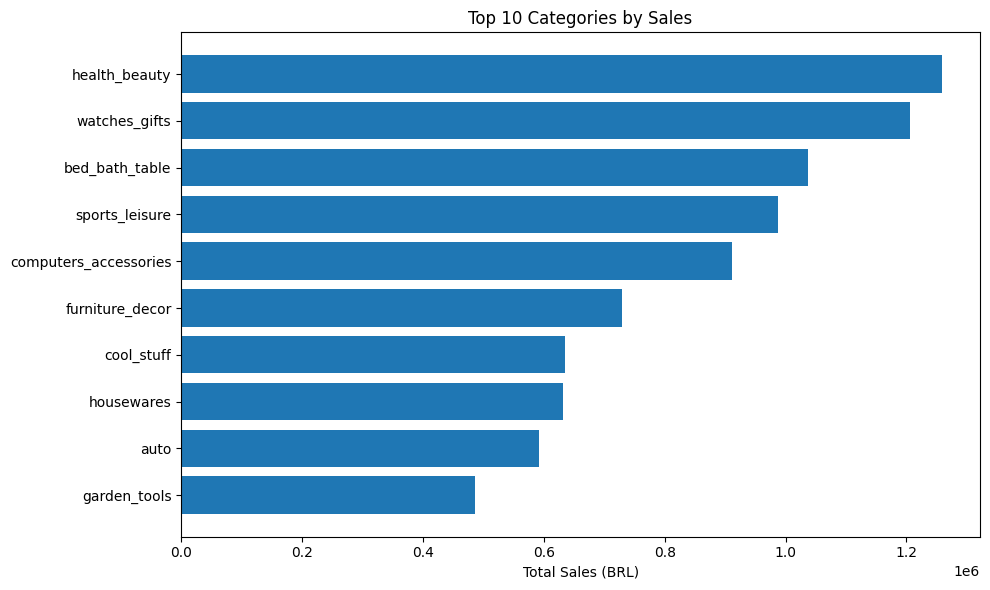

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top10['product_category_name_english'][::-1], top10['total_sales'][::-1])
plt.xlabel('Total Sales (BRL)')
plt.title('Top 10 Categories by Sales')
plt.tight_layout()
plt.show()


1위, 2위 격차 거의 없음 — 시각적으로 즉시 확인 가능

5위(computers_accessories)에서 6위(furniture_decor) 구간에 뚜렷한 계단 존재 — 상위 5개가 하나의 그룹

cool_stuff와 housewares 길이 거의 동일 — 수치보다 직관적으로 파악됨